# Lab 2 - My solutions
**Graphical representation of functions**<br>
Software 1 - Mathematics<br>
Information and Communication Technology<br>
Metropolia University of Applied Sciences

## Setup

In [1]:
name = "Muhammad Bilal"
student_id = 2601860
date_returned = "10.03.2026"

In [32]:
from IPython.display import Markdown, display
import numpy as np
import matplotlib.pyplot as plt
import labx as mx # Remenber to donwload labx.pyc from the course website

---
## My solution for problem 1

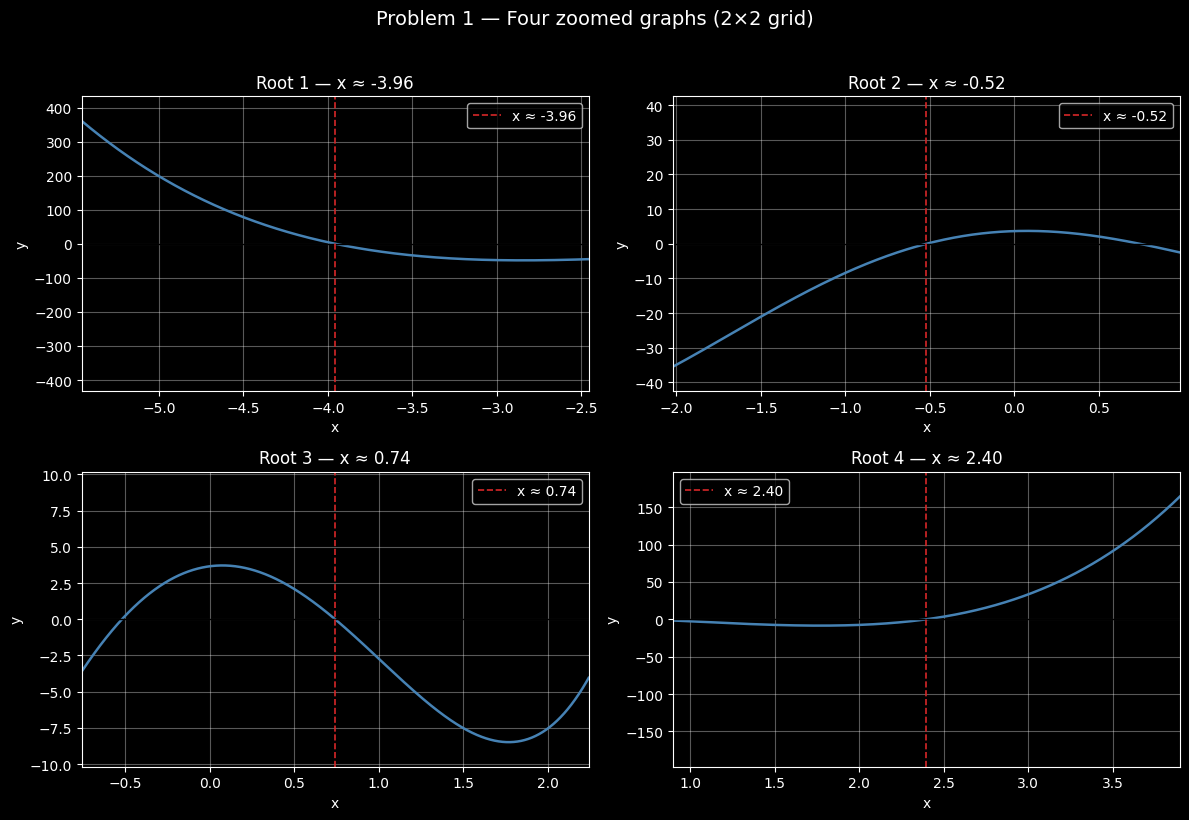

In [33]:
os.makedirs("data", exist_ok=True)

#Sample the function on [-10, 10]

x = np.linspace(-10, 10, 20001)
y = mx.lab_2_problem_1(x, student_id)

def f_scalar(t):
    return mx.lab_2_problem_1(np.array([t]), student_id)[0]

def bisect(a, b, f, tol=1e-9, it=80):
    fa, fb = f(a), f(b)
    if fa == 0: return a
    if fb == 0: return b
    if fa * fb > 0: return None
    for _ in range(it):
        m = 0.5*(a+b)
        fm = f(m)
        if abs(fm) < tol:
            return m
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return 0.5*(a+b)

idx = np.where(np.signbit(y[:-1]) != np.signbit(y[1:]))[0]
roots = []
for i in idx:
    r = bisect(x[i], x[i+1], f_scalar)
    if r is not None and all(abs(r - rr) > 1e-5 for rr in roots):
        roots.append(r)

roots = sorted(roots)[:4]

print("Problem 1 — Roots (x-values):")
for k, r in enumerate(roots, start=1):
    print(f"  Root {k}: x ≈ {r:.6f}")

#Make a single figure with 4 subplots

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for ax, r, k in zip(axs, roots, range(1, len(roots)+1)):
    w = 1.5
    xz = np.linspace(r - w, r + w, 2401)
    yz = mx.lab_2_problem_1(xz, student_id)

#choose y-lims centered around 0 with padding so the x-axis is visible

    yabs = float(np.nanmax(np.abs(yz))) if np.isfinite(yz).any() else 1.0
    pad = max(0.2*yabs, 0.5)

    ax.plot(xz, yz, color="steelblue", lw=1.8)
    ax.axhline(0, color="black", lw=1)
    ax.axvline(r, color="#d62728", ls="--", lw=1.2, label=f"x ≈ {r:.2f}")
    ax.set_xlim(r - w, r + w)
    ax.set_ylim(-yabs - pad, yabs + pad)
    ax.set_title(f"Root {k} — x ≈ {r:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.35)
    ax.legend(loc="best")

#If fewer than 4 roots found, hide unused panels

for j in range(len(roots), 4):
    fig.delaxes(axs[j])

fig.suptitle("Problem 1 — Four zoomed graphs (2×2 grid)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

fig.savefig(os.path.join("data", "problem1_roots_2x2.png"), dpi=150, bbox_inches="tight")

---

## Problem 2

In [34]:
# Run the code below to see your problem text
txt = mx.lab_2_problem_2(student_id)
display(Markdown(txt))


In this problem your task is to plot two functions and
graphically find the intersection points of the two functions.

The first functions is $$ f(x) = \sqrt{3.8x} $$ and 
the second function is $$ g(x) = (x - 3.18)^2 $$.
    
First, plot the two functions in the same graph. Make this first plot to show the functions in the 
larger range of $x$ values, say $x \in [0, 10]$.

Then plot the two functions in another graph, but now show the functions in the smaller range of 
$x$ values. In this second plot, make sure to show the intersection points of the two functions.
What are their values? Find the values *graphically*.

Finally, remember to decorate the plots with title, axis labels, and a legend. Add also grid
lines to the plots to make them easier to read.

### My solution

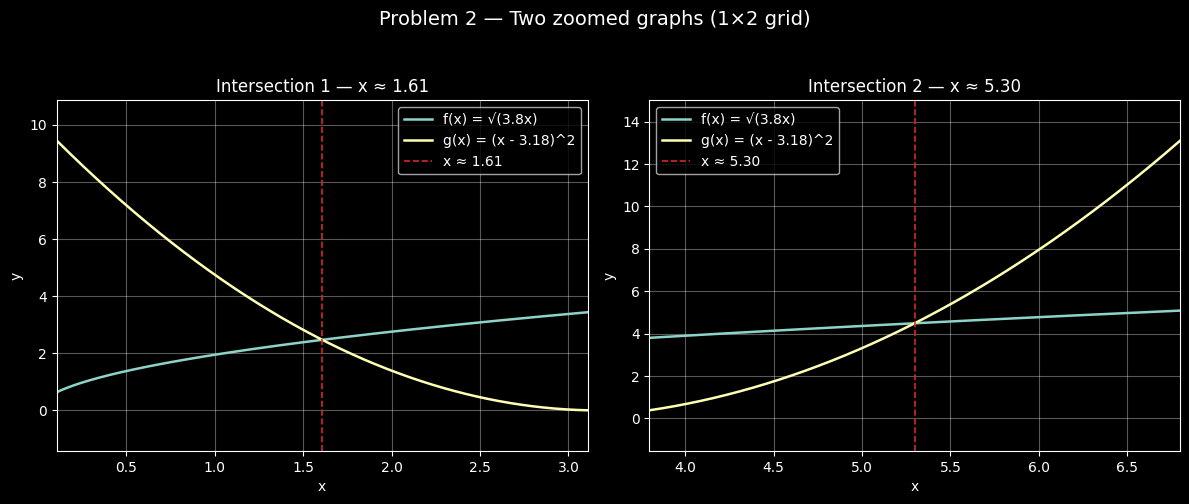

In [35]:
os.makedirs("data", exist_ok=True)

def f(x):
    return np.sqrt(3.8 * x)

def g(x):
    return (x - 3.18)**2

def safe(fun, x):
    y = np.array(fun(x), dtype=float)
    y[~np.isfinite(y)] = np.nan
    return y

X = np.linspace(0, 10, 40001)
def h(z):
    return f(z) - g(z)

H = safe(h, X)
idx = np.where(np.signbit(H[:-1]) != np.signbit(H[1:]))[0]

def bisect(a, b, func, tol=1e-9, it=80):
    fa, fb = func(a), func(b)
    if not np.isfinite(fa) or not np.isfinite(fb):
        return None
    if fa == 0: return a
    if fb == 0: return b
    if fa * fb > 0: return None
    for _ in range(it):
        m = 0.5*(a+b)
        fm = func(m)
        if not np.isfinite(fm):
            b = m
            continue
        if abs(fm) < tol:
            return m
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return 0.5*(a+b)

inters = []
for i in idx:
    r = bisect(X[i], X[i+1], h)
    if r is not None and all(abs(r - rr) > 1e-5 for rr in inters):
        inters.append(r)

inters = sorted(inters)[:2]

print("Problem 2 — Intersections (x-values):")
for k, r in enumerate(inters, start=1):
    print(f"  Intersection {k}: x ≈ {r:.6f}")

#make a single figure with 2 subplots

fig, axs = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, r, k in zip(axs, inters, range(1, len(inters)+1)):
    w = 1.5
    Xz = np.linspace(r - w, r + w, 2401)
    Yfz = safe(f, Xz)
    Ygz = safe(g, Xz)

#y-lims based on data

    ycat = np.concatenate([Yfz[np.isfinite(Yfz)], Ygz[np.isfinite(Ygz)]])
    if ycat.size:
        ymin, ymax = float(np.nanmin(ycat)), float(np.nanmax(ycat))
        pad = 0.15 * max(1.0, ymax - ymin)
        ymin, ymax = ymin - pad, ymax + pad
    else:
        ymin, ymax = -1, 1

    ax.plot(Xz, Yfz, label="f(x) = √(3.8x)", lw=1.8)
    ax.plot(Xz, Ygz, label="g(x) = (x - 3.18)^2", lw=1.8)
    ax.axvline(r, color="#d62728", ls="--", lw=1.2, label=f"x ≈ {r:.2f}")
    ax.set_xlim(r - w, r + w)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"Intersection {k} — x ≈ {r:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.35)
    ax.legend(loc="best")

if len(inters) < 2:
    for j in range(len(inters), 2):
        fig.delaxes(axs[j])

fig.suptitle("Problem 2 — Two zoomed graphs (1×2 grid)", fontsize=14, y=1.04)
fig.tight_layout()
plt.show()

fig.savefig(os.path.join("data", "problem2_intersections_1x2.png"), dpi=150, bbox_inches="tight")